In [18]:
#a)

import numpy as np
import matplotlib.pyplot as plt

def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  # noise level: explore it!
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

xx = np.linspace(-1, 1, 400)
#plt.plot(xx, runge(xx), color="#004488", label="Runge's function")
#plt.scatter(x, y, s=12, color="#BB5566", label=rf"data, $\sigma={sigma}$")
#plt.xlabel("x"); plt.ylabel("y"); plt.legend(frameon=False)
#plt.show()




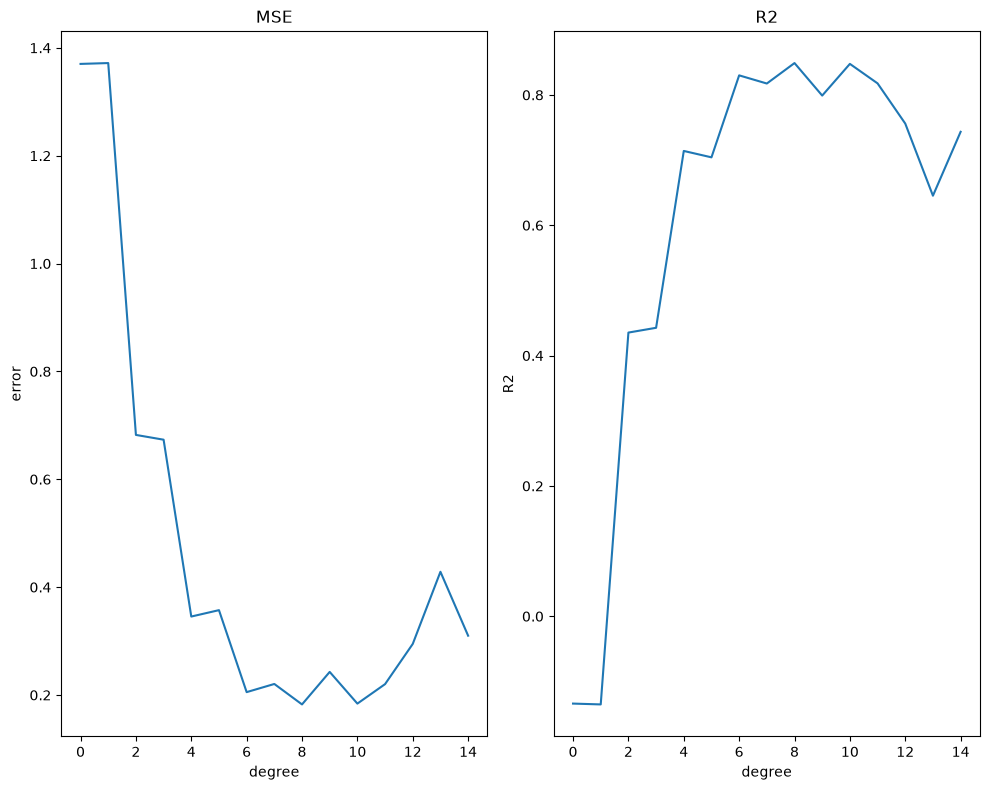

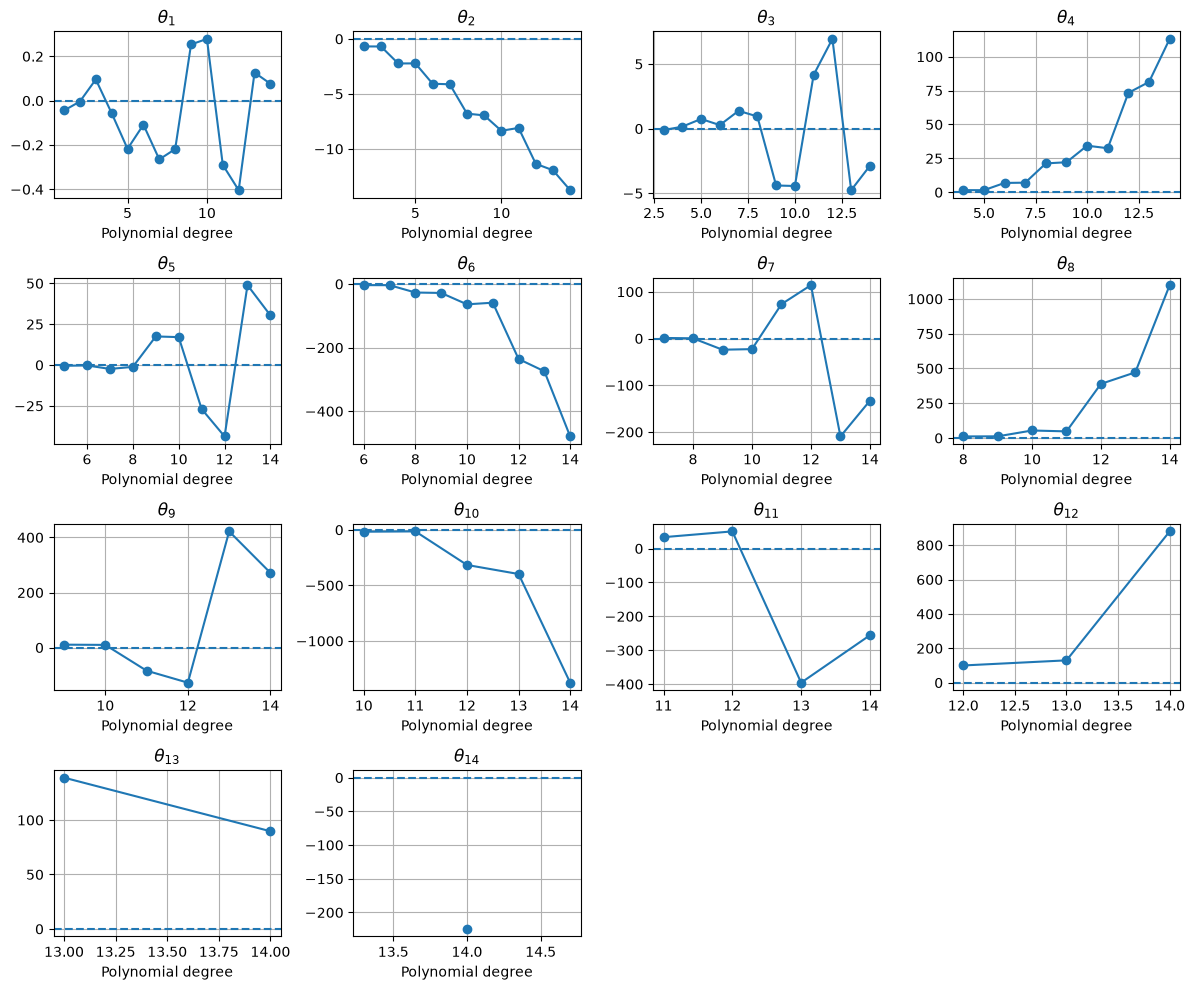

MSE coeffs polynomial degree 5: [-0.020156102051171566, -0.21725503045423158, -2.2266958782468094, 0.7504325845647202, 1.5673192141652652, -0.4540749631354588]


In [19]:
from sklearn.model_selection import train_test_split

maxdegree = 15
degrees = np.arange(maxdegree)
MSE = np.zeros(maxdegree)
R2 = np.zeros(maxdegree)

coeffs = [np.zeros(maxdegree-i) for i in range(maxdegree)]
y_std = (y-np.mean(y))/np.sqrt(np.var(y))


for degree in degrees:
    X = design_matrix(x, degree)
    X_mean = X - np.mean(X, axis = 0, keepdims = True)
    X_std = np.empty((n, degree+1))
    X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
    X_std[:,0] = np.ones(n)

    Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state= 2026)

    coeff = np.zeros(degree+1)

    U, s, Vt = np.linalg.svd(Xtrain)


    s_inv = np.zeros((degree+1,len(Ytrain)))
    s_inv[:,:degree+1] += np.diag(1/s)
    coeff = Vt.T@s_inv@U.T@Ytrain

    for i in range(degree+1):
        coeffs[i][degree-i] = coeff[i]

    y_pred = Xtest@coeff

    y_mean = np.mean(Ytest)

    MSE[degree] = np.mean((y_pred-Ytest)**2)
    R2[degree] = 1-np.mean((y_pred-Ytest)**2)/np.mean((Ytest-y_mean)**2)

#plt.plot(degrees, MSE)
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
axes[0].plot(degrees,MSE)
axes[0].set_title("MSE")
axes[0].set_xlabel("degree")
axes[0].set_ylabel("error")

axes[1].plot(degrees,R2)
axes[1].set_title("R2")
axes[1].set_xlabel("degree")
axes[1].set_ylabel("R2")

plt.tight_layout()
plt.plot()
plt.show()


#plotter koeffesientene unntat intercept fordi det er alltid 0
#----!!! KODE her laget av ChatGPT !!!----:
# Plot each coefficient separately
square = int(np.sqrt(maxdegree))+1
fig, axes = plt.subplots(
    square, square,
    figsize=(12, 10)
)

axes = axes.flatten()

for i in range(1, maxdegree):
    degrees_i = np.arange(i, maxdegree)

    axes[i - 1].plot(
        degrees_i,
        coeffs[i],
        marker="o",
        linestyle="-"
    )

    axes[i - 1].axhline(0, linestyle="--")

    axes[i - 1].set_title(rf"$\theta_{{{i}}}$")
    axes[i - 1].set_xlabel("Polynomial degree")
    axes[i - 1].grid(True)

# Hide the unused subplot
for j in range(maxdegree - 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
#----------------------------------------
coeffs_degree_5 = [float(coeffs[i][5-i]) for i in range(6)]
print("MSE coeffs polynomial degree 5:", coeffs_degree_5)


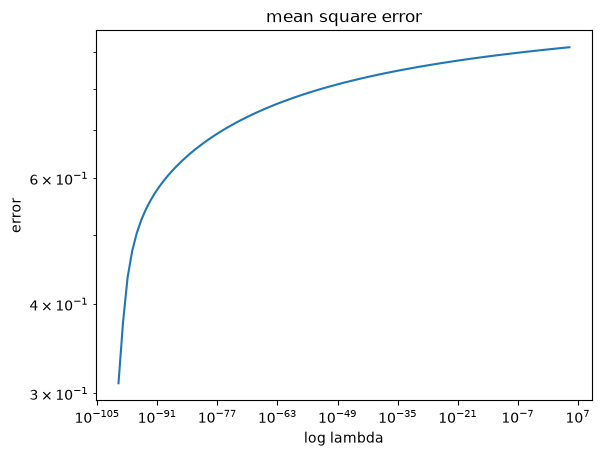

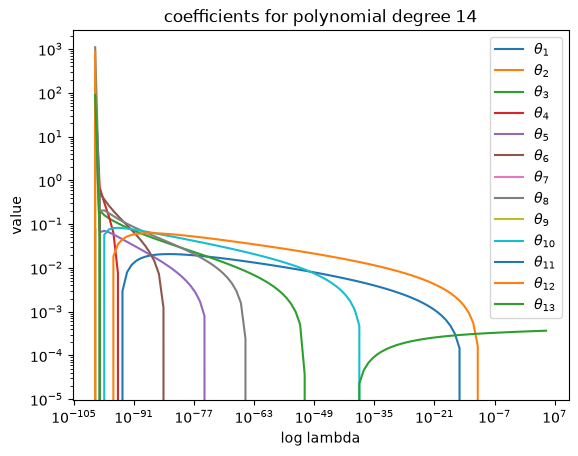

min mse:  0.30999668849625467
lambda:  1e-100


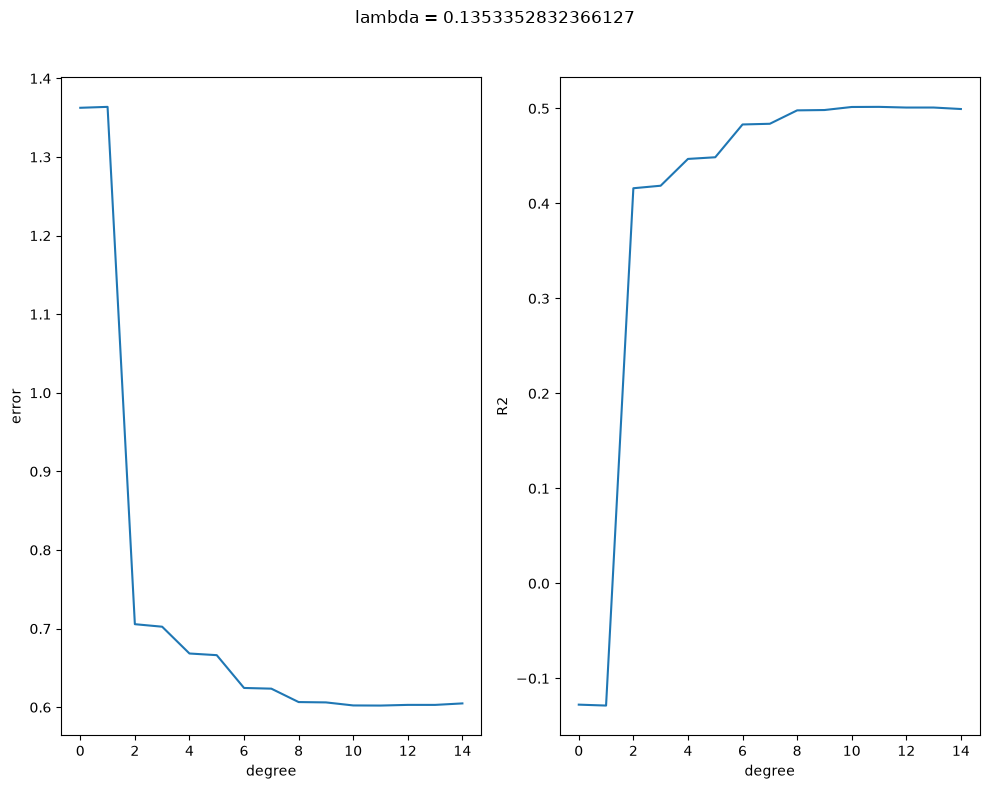

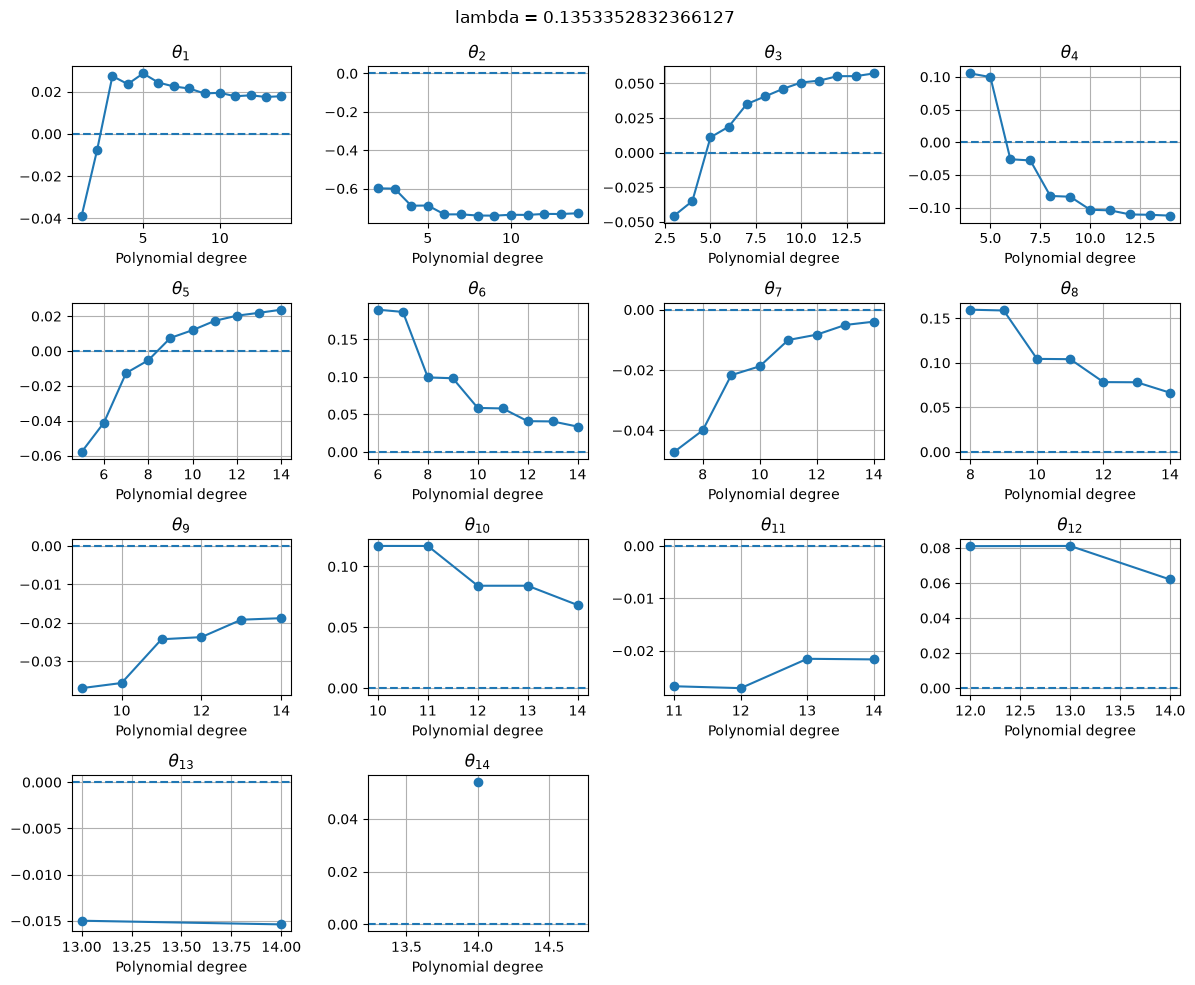

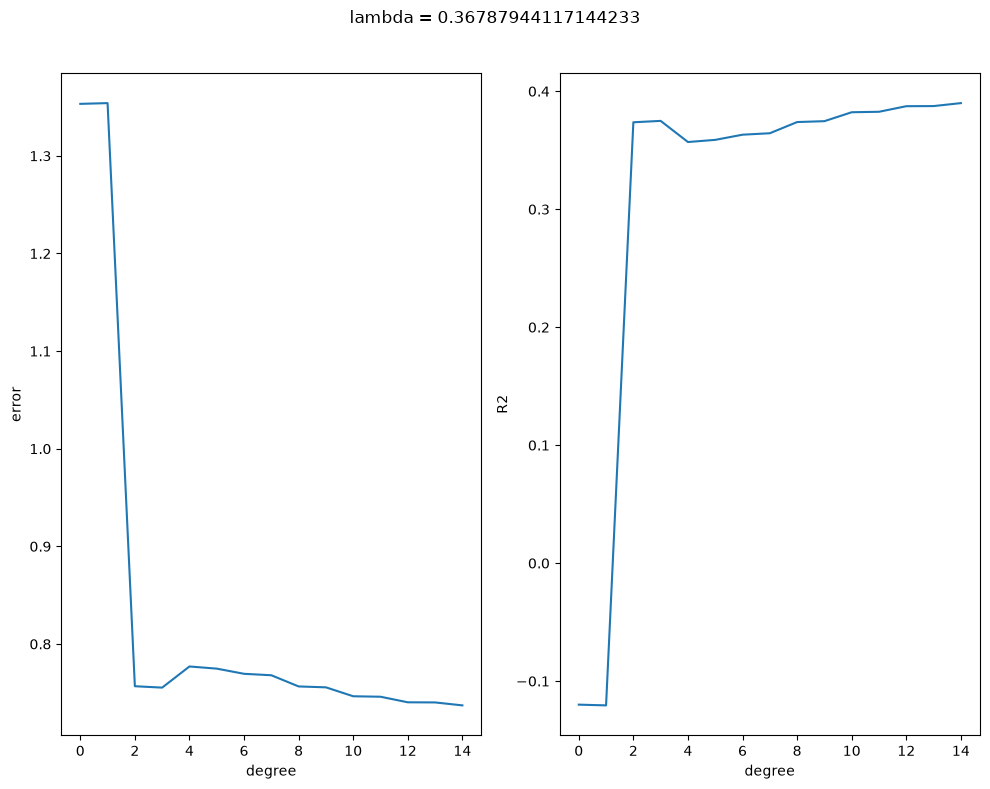

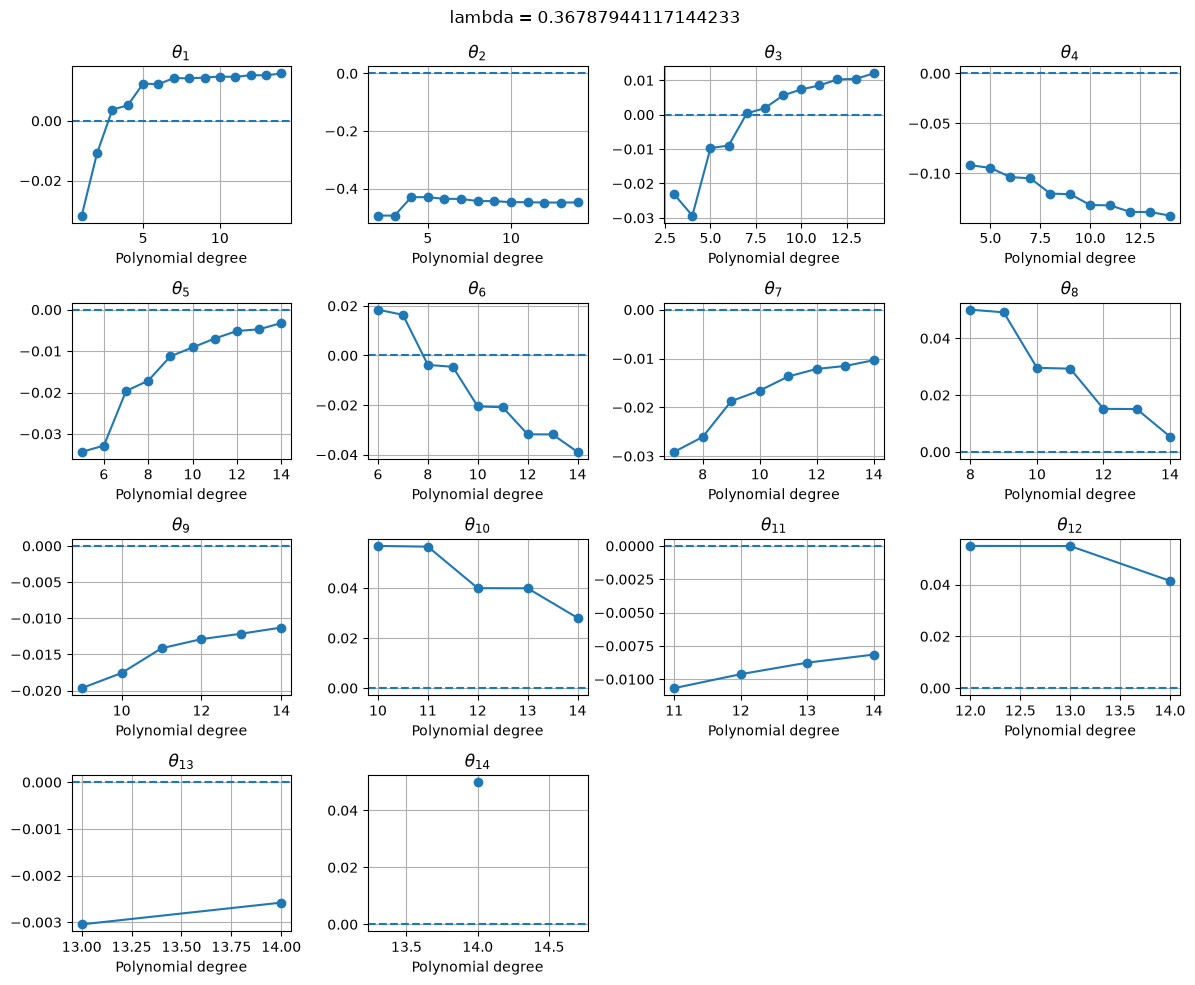

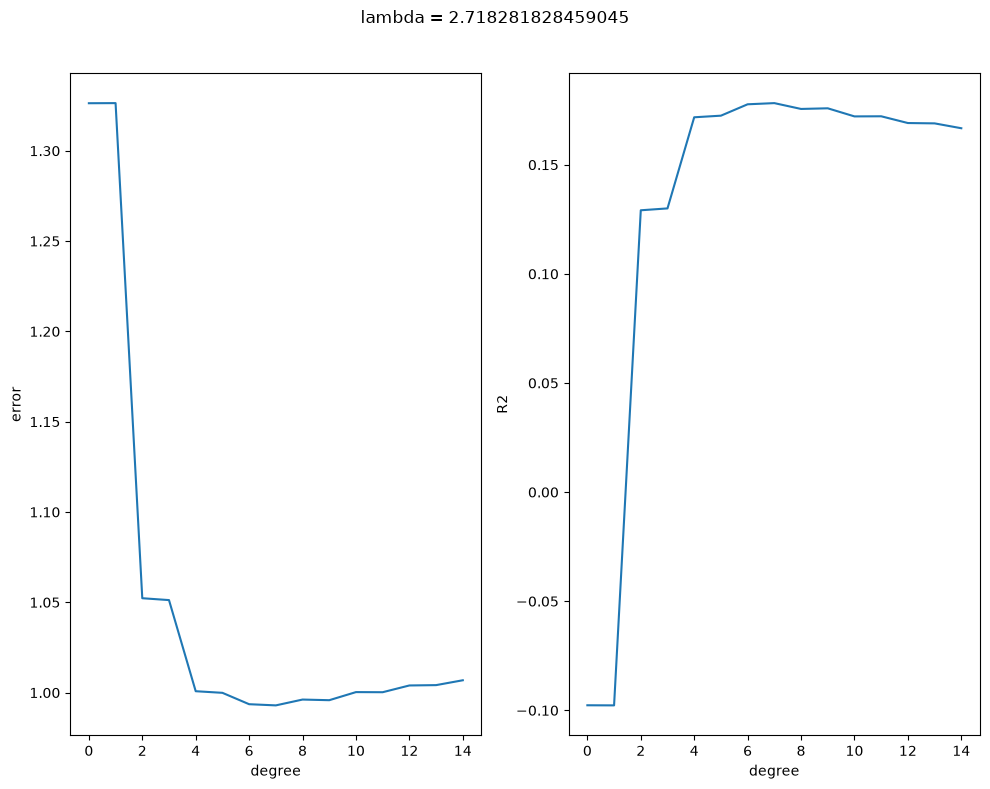

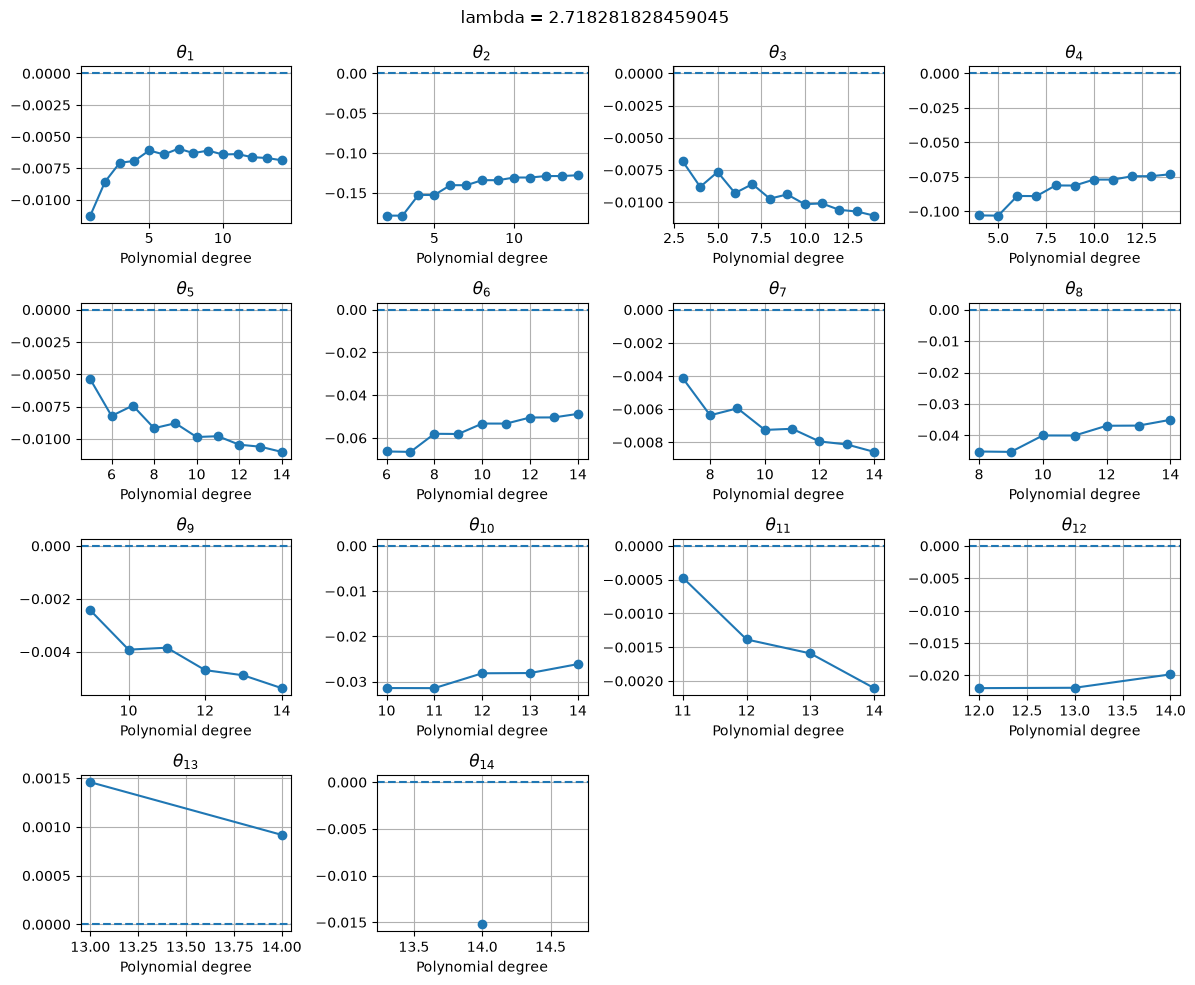

[ 0.01587233  0.02862224 -0.6885043   0.01109006  0.09957797 -0.05788124]


In [20]:
#b
n = 100

degree = 14

X = design_matrix(x, degree)
X_mean = X - np.mean(X, axis = 0, keepdims = True)
X_std = np.empty((n, degree+1))
X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
X_std[:,0] = np.ones(n)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state=2026)

n_train = len(Xtrain[:,0])

lambda_num = 100
lam_borders = -5,5
lam = np.logspace(-100, 5, lambda_num)

train_len = len(Ytrain)

MSE = np.zeros(lambda_num)
R2  = np.zeros(lambda_num)

coeffs = np.zeros((lambda_num, degree+1))

for l in range(lambda_num):

    se = 0

    U, s, Vt = np.linalg.svd(Xtrain)
    s2= np.diag(s**2)
    inv_mat = Vt.T@s2@Vt+np.identity(degree+1)*l
    coeff = np.linalg.solve(inv_mat, Xtrain.T@Ytrain)
    y_pred = Xtest@coeff
    
    y_mean = np.mean(Ytest)

    coeffs[l] = coeff

    MSE[l] = np.mean((y_pred-Ytest)**2)
    R2[l] = 1-np.mean((y_pred-Ytest)**2)/np.mean((Ytest-y_mean)**2)

plt.plot(lam, MSE)
plt.title("mean square error")
plt.ylabel("error")
plt.xlabel("log lambda")
plt.yscale("log")
plt.xscale("log")
plt.show()

for i in range(1,degree):
    plt.plot(lam, coeffs[:,i])
plt.title("coefficients for polynomial degree 14")
plt.ylabel("value")
plt.xlabel("log lambda")
plt.yscale("log")
plt.xscale("log")
plt.legend([r"$\theta_{"+str(i+1)+"}$" for i in range(degree)])
plt.show()

print("min mse: ",np.min(MSE))
print("lambda: ",lam[np.argmin(MSE)])


"""

HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

"""

maxdegree = 15
degrees = np.arange(maxdegree)
loglambdas = np.array([-2,-1,1])

lambdas = np.exp(loglambdas)

recorded_coeff = np.zeros(6)

for j,l in enumerate(lambdas):
    MSE = np.zeros(maxdegree)
    R2 = np.zeros(maxdegree)

    coeffs = [np.zeros(maxdegree-i) for i in range(maxdegree)]
    y_std = (y-np.mean(y))/np.sqrt(np.var(y))


    for degree in degrees:
        X = design_matrix(x, degree)
        X_mean = X - np.mean(X, axis = 0, keepdims = True)
        X_std = np.empty((n, degree+1))
        X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
        X_std[:,0] = np.ones(n)

        Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state=2026)

        coeff = np.linalg.solve(Xtrain.T@Xtrain+np.identity(degree+1)*l*n_train, Xtrain.T@Ytrain)
        y_pred = Xtest@coeff

        for i in range(degree+1):
            coeffs[i][degree-i] = coeff[i]

        y_pred = Xtest@coeff

        y_mean = np.mean(Ytest)

        MSE[degree] = np.mean((y_pred-Ytest)**2)
        R2[degree] = 1-np.mean((y_pred-Ytest)**2)/np.mean((Ytest-y_mean)**2)

        if degree == 5 and j == 0:
            recorded_coeff = coeff


    #plt.plot(degrees, MSE)
    fig, axes = plt.subplots(1, 2, figsize=(10, 8))
    axes[0].plot(degrees,MSE)
    axes[0].set_xlabel("degree")
    axes[0].set_ylabel("error")

    axes[1].plot(degrees,R2)
    axes[1].set_xlabel("degree")
    axes[1].set_ylabel("R2")

    fig.suptitle("lambda = "+str(l))#<---- Disse to linjene er fra ChatGPT
    plt.tight_layout(rect=[0, 0, 1, 0.96]) #<--- og her
    plt.plot()
    plt.show()


    #plotter koeffesientene unntat intercept fordi det er alltid 0
    #----!!! KODE her laget av ChatGPT !!!----:
    # Plot each coefficient separately
    square = int(np.sqrt(maxdegree))+1
    fig, axes = plt.subplots(
        square, square,
        figsize=(12, 10)
    )

    axes = axes.flatten()

    for i in range(1, maxdegree):
        degrees_i = np.arange(i, maxdegree)

        axes[i - 1].plot(
            degrees_i,
            coeffs[i],
            marker="o",
            linestyle="-"
        )

        axes[i - 1].axhline(0, linestyle="--")

        axes[i - 1].set_title(rf"$\theta_{{{i}}}$")
        axes[i - 1].set_xlabel("Polynomial degree")
        axes[i - 1].grid(True)

    # Hide the unused subplot
    for j in range(maxdegree - 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.suptitle("lambda = "+str(l))
    plt.show()
    #----------------------------------------
print(recorded_coeff)



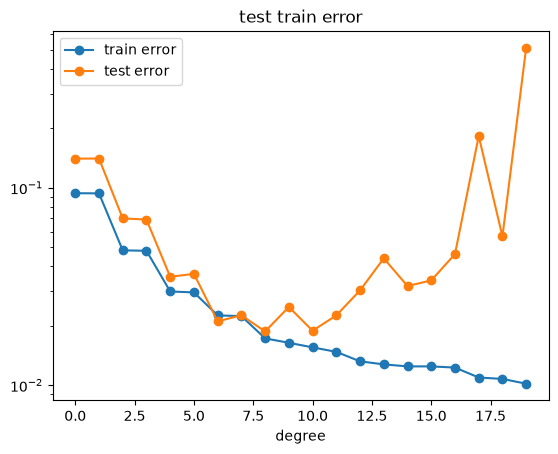

In [21]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.2, random_state=2026)
from sklearn.metrics import mean_squared_error

maxdegree = 20
train_error = np.zeros(maxdegree)
test_error = np.zeros(maxdegree)
for degree in range(maxdegree):
    Xtrain = design_matrix(xtrain, degree)

    coeff = np.zeros(degree+1)

    U, s, Vt = np.linalg.svd(Xtrain)
    s_inv = np.zeros((degree+1,len(Ytrain)))
    s_inv[:,:degree+1] += np.diag(1/s)
    coeff = Vt.T@s_inv@U.T@ytrain #<-- ChatGPT fikset en bug her, der jeg hadde skrevet Ytrain i stedet.

    Xtest = design_matrix(xtest, degree)
    y_pred_test = Xtest@coeff
    y_pred_train = Xtrain@coeff

    test_error[degree] = mean_squared_error(y_pred_test, ytest)
    train_error[degree] = mean_squared_error(y_pred_train, ytrain)

degrees = np.arange(maxdegree)
plt.plot(degrees, train_error, marker = "o", linestyle ="-")
plt.plot(degrees, test_error, marker = "o", linestyle = "-")
plt.legend(["train error", "test error"])
plt.xlabel("degree")
plt.yscale("log")
plt.title("test train error")
plt.show()



$$
\mathbb{E}((y-\tilde{y})^2) = \mathbb{E}((y-\mathbb{E}(\tilde{y}))-(\tilde{y}-\mathbb{E}(\tilde{y}))^2)\\
=\mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)+\mathbb{E}((\tilde{y}-\mathbb{E}(\tilde{y}))^2)+2\mathbb{E}((y-\mathbb{E}(\tilde{y}))(\tilde{y}-\mathbb{E}(\tilde{y}))=\\ \mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)+\mathbb{E}((\tilde{y}-\mathbb{E}(\tilde{y}))^2)+2\mathbb{E}(y-\mathbb{E}(\tilde{y}))\mathbb{E}(\tilde{y}-\mathbb{E}(\tilde{y}))=\\ \mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)+\mathbb{E}((\tilde{y}-\mathbb{E}(\tilde{y}))^2)+2\mathbb{E}(y-\mathbb{E}(\tilde{y}))(\mathbb{E}(\tilde{y})-\mathbb{E}(\tilde{y}))=\mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)+\mathbb{E}((\tilde{y}-\mathbb{E}(\tilde{y}))^2)
$$
Jeg ser nå på $\mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)$:

$$
\mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)=\mathbb{E}((f+\epsilon-\mathbb{E}[\tilde{y}])^2)=\mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2+\epsilon^2+2\epsilon(f-\mathbb{E}[\tilde{y}])] =\\ \mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2]+\mathbb{E}[\epsilon^2]+2\mathbb{E}[\epsilon(f-\mathbb{E}[\tilde{y}])]=\mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2]+\mathbb{E}[\epsilon^2]+2\mathbb{E}[\epsilon]\mathbb{E}[(f-\mathbb{E}[\tilde{y}])]=\\
\mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2]+\mathbb{E}[\epsilon^2]=\mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2]+\sigma^2
$$

Hvis jeg nå setter alt sammen:
$$
\mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)=\mathbb{E}((\tilde{y}-\mathbb{E}(\tilde{y}))^2)+\mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2]+\sigma^2 \\ =\frac{1}{n}\sum_i(f_i-\mathbb{E}(\tilde{y}))^2+\frac{1}{n}\sum_i(\tilde{y}_i-\mathbb{E}(\tilde{y}))^2+\sigma^2
$$

Jeg ser på hva som skjer om man erstatter f med y i bias leddet:

$$
\mathbb{E}[((y_{test})-\tilde{y})^2] = \mathbb{E}[(f+\sigma+\tilde{y})]^2 =\\ \mathbb{E}[(f+\tilde{y})^2]+\mathbb{E}[\sigma^2]+2\mathbb{E}[(f+\tilde{y})\sigma] = \mathbb{E}[(f+\tilde{y})^2]+E[\sigma^2]+2E[(f+\tilde{y})]\mathbb{E}[\sigma] =  \mathbb{E}[(f+\tilde{y})^2]+\sigma^2
$$

Dermed kan man se at Bias slik den er definert med $y_{test}$ i stedet for $f$ blir større på grunn av $\sigma$, så den printete identiteten kommer er ikke lik i teorien.

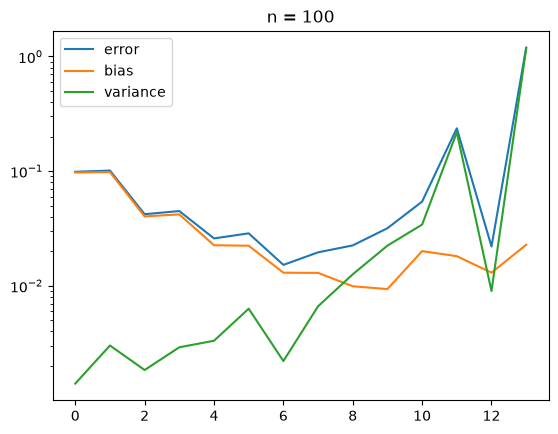

min error:  0.015214919544904651
degree with min error:  6


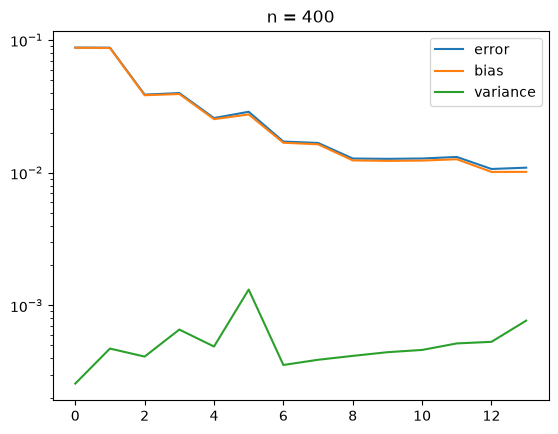

min error:  0.010683478715911278
degree with min error:  12


In [22]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils import resample

np.random.seed(2026)
ns = [100, 400]
n_bootstraps, maxdegree = 100, 14

for n in ns:
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)

    x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state= 2026)

    x_train = x_train.reshape(-1,1)
    x_test = x_test.reshape(-1,1)

    error = np.zeros(maxdegree)
    bias = np.zeros(maxdegree)
    variance = np.zeros(maxdegree)

    for deg in range(maxdegree):
        model = make_pipeline(PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))

        y_pred = np.empty((len(y_test), n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:,i] = model.fit(x_,y_).predict(x_test).ravel()

        error[deg] = np.mean(np.mean((y_test[:, None]-y_pred)**2, axis = 1))#<- ChatGPT fikset indekserings feil
        bias[deg] = np.mean((y_test - np.mean(y_pred, axis = 1))**2)#<- ChatGPT fikset indekseringsfeil her.
        variance[deg] = np.mean(np.var(y_pred, axis = 1))
        

    x_axis = np.arange(maxdegree)
    plt.yscale("log")
    plt.title("n = "+str(n))
    plt.plot(x_axis, error)
    plt.plot(x_axis, bias)
    plt.plot(x_axis, variance)
    plt.legend(["error","bias", "variance"])


    plt.show()
    print("min error: ",np.min(error))
    print("degree with min error: ",np.argmin(error))


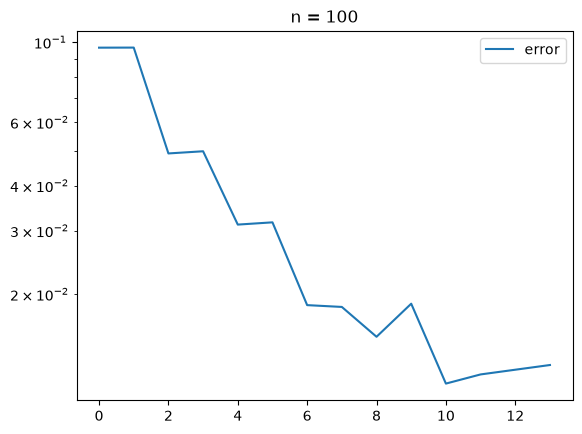

min error:  0.01128922344719185
degree with min error:  10


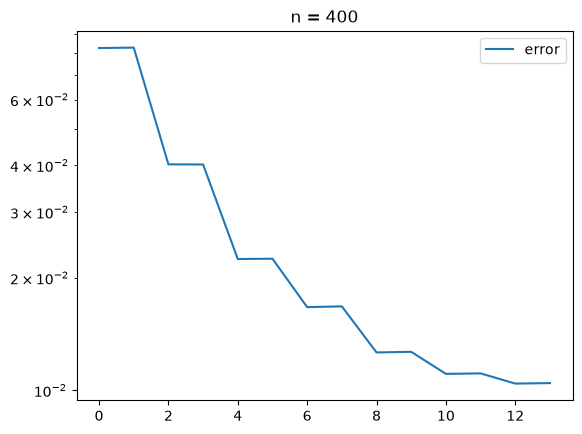

min error:  0.010419013932380917
degree with min error:  12


In [23]:
#d
from sklearn.model_selection import train_test_split, KFold, cross_val_score

np.random.seed(2026)
ns = [100,400]
maxdegree = 14
splits = 10
for n in ns:
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)

    kf = KFold(n_splits = splits, shuffle = True, random_state=2026)

    MSE = np.zeros(maxdegree)

    for deg in range(maxdegree):
        mse = np.zeros(splits)

        model = make_pipeline(PolynomialFeatures(degree = deg), LinearRegression(fit_intercept= False))

        for i, (train_idx, test_idx) in enumerate(kf.split(x)):
            y_pred = model.fit(x.reshape(-1,1)[train_idx], y[train_idx]).predict(x.reshape(-1,1)[test_idx])
            y_test = y[test_idx]

            mse[i] = np.mean((y_pred-y_test)**2)

        MSE[deg] = np.mean(mse)

    x_axis = np.arange(maxdegree)
    plt.yscale("log")
    plt.title("n = "+str(n))
    plt.plot(x_axis, MSE)
    plt.legend(["error","bias", "variance"])


    plt.show()
    print("min error: ",np.min(MSE))
    print("degree with min error: ",np.argmin(MSE))

In [37]:
#Gradients:
#This was taken from the project task page:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)   # 64-bit floats, as in numpy
from jax import grad

degree, lmbda = 5, 1e-2
X = design_matrix(x, degree)
theta0 = rng.normal(size=X.shape[1])

def cost_ols(theta, X, y):
    return jnp.mean((y - X @ theta)**2)

def cost_ridge(theta, X, y, lmbda):
    return jnp.mean((y - X @ theta)**2) + lmbda * jnp.sum(theta**2)

# gradients by automatic differentiation (with respect to argument 0 = theta)
grad_ols_ad = jax.grad(cost_ols)
grad_ridge_ad = jax.grad(cost_ridge)

# the same gradients by hand
grad_ols_analytic = 2.0 / len(y) * X.T @ (X @ theta0 - y)
grad_ridge_analytic = grad_ols_analytic + 2.0 * lmbda * theta0

print("OLS   max |AD - analytic| =", np.max(np.abs(grad_ols_ad(theta0, X, y) - grad_ols_analytic)))
print("Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X, y, lmbda) - grad_ridge_analytic)))

# the largest safe learning rate for plain gradient descent: eta < 2 / lambda_max(Hessian)
H = 2.0 / len(y) * X.T @ X
print("eta_max for OLS  =", 2.0 / np.linalg.eigvalsh(H).max())
n=n

OLS   max |AD - analytic| = 2.220446049250313e-16
Ridge max |AD - analytic| = 2.220446049250313e-16
eta_max for OLS  = 0.8937721839600535


In [ ]:
#e
rng = np.random.default_rng(2026)
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)
n=100
X = design_matrix(x, degree)

X_mean = X - np.mean(X, axis = 0, keepdims = True)
X_std = np.empty((n, degree+1))
X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
X_std[:,0] = np.ones(n)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state= 2026)

X_norm5 = Xtrain


n_train = len(X_norm5[:,0])

n_features5 = X_norm5.shape[1]

Hessian = (2/n_train)*X_norm5.T@X_norm5
eig = np.linalg.eigvalsh(Hessian)
gamma_opt = 2/(eig[0]+eig[-1])


# Gradient descent parameters, learning rate gamma first
# Then the maximum number of iterations, and a tolerance for the stopping criterion
num_iters = 100000
tol = 1e-8 #<-ChatGPT fikset stoppe kriteriet
lam = np.exp(-2)


# Initialize weights for gradient descent


learning_rates = [0.99*gamma_opt, gamma_opt, 1.02*gamma_opt]

recorded_theta_OLS = np.zeros(n_features5)

#OLS
# Gradient descent loop
gamma = gamma_opt

theta_gdOLS = np.zeros(n_features5)
for t in range(num_iters):
    # Compute gradients for OLS and Ridge
    grad_OLS = (2/n_train)*X_norm5.T@(X_norm5@theta_gdOLS - Ytrain)
    # Update parameters theta
    theta_gdOLS = theta_gdOLS - gamma_opt*grad_OLS
    if np.linalg.norm(grad_OLS)<tol:
        break

actual_iters_OLS = t

#Ridge:

Hessian_Ridge = (2/n_train)*X_norm5.T@X_norm5+2*lam*np.identity(n_features5)
eig_Ridge = np.linalg.eigvalsh(Hessian_Ridge)
gamma_opt_Ridge = 2/(eig_Ridge[0]+eig_Ridge[-1])


# Gradient descent loop
theta_gdRidge = np.zeros(n_features5)
for t in range(num_iters):
    # Compute gradients for OLS and Ridge
    grad_Ridge = (2/n_train)*X_norm5.T@(X_norm5@theta_gdRidge - Ytrain) + 2*lam*theta_gdRidge
    # Update parameters theta
    theta_gdRidge = theta_gdRidge - gamma_opt_Ridge*grad_Ridge
    if np.linalg.norm(grad_Ridge)<tol:
        break

actual_iters_Ridge = t


print("OLS:")
print("theta:", theta_gdOLS)
print("iterations for gamma: ",int(actual_iters_OLS))
print("condition number: ", (eig[-1]/eig[0]))
print("min eig: ",eig[0]," max eig: ", eig[-1])
print("")
print("Ridge")
print("theta:", theta_gdRidge)
print("iterations for gamma: ",int(actual_iters_Ridge))
print("condition number: ", (eig_Ridge[-1]/eig_Ridge[0]))
print("min eig: ",eig_Ridge[0]," max eig: ", eig_Ridge[-1])

(100, 6)
OLS:
theta: [-0.0201561  -0.21725501 -2.22669588  0.75043252  1.56731922 -0.45407491]
iterations for gamma:  3952
condition number:  491.41312071818305
min eig:  0.010358962240372332  max eig:  5.090529961943189

Ridge
theta: [ 0.01587233  0.02862224 -0.6885043   0.01109006  0.09957797 -0.05788124]
iterations for gamma:  154
condition number:  19.077000744217575
min eig:  0.2810295287135975  max eig:  5.361200528416413


In [45]:
#e jax
rng = np.random.default_rng(2026)
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)
n=100
X = design_matrix(x, degree)

print(np.shape(X))
X_mean = X - np.mean(X, axis = 0, keepdims = True)
X_std = np.empty((n, degree+1))
X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
X_std[:,0] = np.ones(n)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state= 2026)

X_norm5 = Xtrain


n_train = len(X_norm5[:,0])

n_features5 = X_norm5.shape[1]

Hessian = (2/n_train)*X_norm5.T@X_norm5
eig = np.linalg.eigvalsh(Hessian)
gamma_opt = 2/(eig[0]+eig[-1])


# Gradient descent parameters, learning rate gamma first
# Then the maximum number of iterations, and a tolerance for the stopping criterion
num_iters = 5000
tol = 1e-8 #<-ChatGPT fikset stoppe kriteriet
lam = np.exp(-2)


# Initialize weights for gradient descent


learning_rates = [0.99*gamma_opt, gamma_opt, 1.02*gamma_opt]

recorded_theta_OLS = np.zeros(n_features5)

#OLS
# Gradient descent loop
gamma = gamma_opt

theta_gdOLS = np.zeros(n_features5)
for t in range(num_iters):
    # Compute gradients for OLS and Ridge
    grad_OLS = grad_OLS = grad(cost_ols)(theta_gdOLS, jnp.asarray(X_norm5), jnp.asarray(Ytrain))
    # Update parameters theta
    theta_gdOLS = theta_gdOLS - gamma_opt*grad_OLS
    if np.linalg.norm(grad_OLS)<tol:
        break

actual_iters_OLS = t

#Ridge:

Hessian_Ridge = (2/n_train)*X_norm5.T@X_norm5+2*lam*np.identity(n_features5)
eig_Ridge = np.linalg.eigvalsh(Hessian_Ridge)
gamma_opt_Ridge = 2/(eig_Ridge[0]+eig_Ridge[-1])


# Gradient descent loop
theta_gdRidge = np.zeros(n_features5)
for t in range(num_iters):
    # Compute gradients for OLS and Ridge
    grad_Ridge = grad(cost_ridge)(theta_gdRidge, jnp.asarray(X_norm5), jnp.asarray(Ytrain), lam)#<- ChatGPT fant bug her, jeg hadde skrevet theta_gdOLS i stedet for Ridge
    # Update parameters theta
    theta_gdRidge = theta_gdRidge - gamma_opt_Ridge*grad_Ridge
    if np.linalg.norm(grad_Ridge)<tol:
        break

actual_iters_Ridge = t


print("OLS:")
print("theta:", theta_gdOLS)
print("iterations for gamma: ",int(actual_iters_OLS))
print("condition number: ", (eig[-1]/eig[0]))
print("min eig: ",eig[0]," max eig: ", eig[-1])
print("")
print("Ridge")
print("theta:", theta_gdRidge)
print("iterations for gamma: ",int(actual_iters_Ridge))
print("condition number: ", (eig_Ridge[-1]/eig_Ridge[0]))
print("min eig: ",eig_Ridge[0]," max eig: ", eig_Ridge[-1])

(100, 6)
OLS:
theta: [-0.0201561  -0.21725501 -2.22669588  0.75043252  1.56731922 -0.45407491]
iterations for gamma:  3952
condition number:  491.41312071818305
min eig:  0.010358962240372332  max eig:  5.090529961943189

Ridge
theta: [ 0.01587233  0.02862224 -0.6885043   0.01109006  0.09957797 -0.05788124]
iterations for gamma:  154
condition number:  19.077000744217575
min eig:  0.2810295287135975  max eig:  5.361200528416413


In [ ]:
#f
rng = np.random.default_rng(2026)
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)
n=100
X = design_matrix(x, degree)

X_mean = X - np.mean(X, axis = 0, keepdims = True)
X_std = np.empty((n, degree+1))
X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
X_std[:,0] = np.ones(n)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state= 2026)

X_norm5 = Xtrain


n_train = len(X_norm5[:,0])

n_features5 = X_norm5.shape[1]

Hessian = (2/n_train)*X_norm5.T@X_norm5
eig = np.linalg.eigvalsh(Hessian)
gamma_opt = 2/(eig[0]+eig[-1])

# Gradient descent parameters, learning rate gamma first
# Then the maximum number of iterations, and a tolerance for the stopping criterion
num_iters = 100000
tol = 1e-8 #<-ChatGPT fikset stoppe kriteriet
lam = np.exp(-2)


#Momentum:
gamma = gamma_opt*0.9
beta = 0.9
v = np.zeros(n_features5)
theta_gdOLS = np.zeros(n_features5)
for t in range(1,num_iters+1):
    # Compute gradients for OLS and Ridge
    
    grad_OLS = (2/n_train)*X_norm5.T@(X_norm5@theta_gdOLS - Ytrain)
    v = beta*v + gamma*grad_OLS
    # Update parameters theta
    theta_gdOLS = theta_gdOLS - v
    if np.linalg.norm(grad_OLS)<tol:
        break

actual_iters_OLS_momentum = t

#AdaGrad:
eps = 0.0001
r = np.zeros(n_features5)
theta_gdOLS = np.zeros(n_features5)
for t in range(1,num_iters+1):
    # Compute gradients for OLS and Ridge
    
    grad_OLS = (2/n_train)*X_norm5.T@(X_norm5@theta_gdOLS - Ytrain)
    r = r + grad_OLS**2
    # Update parameters theta
    theta_gdOLS = theta_gdOLS -(gamma*grad_OLS)/np.sqrt(eps+r)
    if np.linalg.norm(grad_OLS)<tol:
        break
actual_iters_OLS_AdaGrad = t

#RMSProp
gamma = 100
rho = 0.1
eps = 0.0001
r = np.zeros(n_features5)
theta_gdOLS = np.zeros(n_features5)
for t in range(1,num_iters+1):
    # Compute gradients for OLS and Ridge
    
    grad_OLS = (2/n_train)*X_norm5.T@(X_norm5@theta_gdOLS - Ytrain)
    r = rho*v + (1-rho)*grad_OLS**2
    # Update parameters theta
    theta_gdOLS = theta_gdOLS - gamma*grad_OLS/(np.sqrt(r)+eps) #<- ChatGPT påpekte at jeg hadde skrevet oppdateringen her feil
    if np.linalg.norm(grad_OLS)<tol:
        break

actual_iters_OLS_RMSProp = t

#Adam
beta1 = 0.9
beta2 = 0.999
eps = 0.0001
theta_gdOLS = np.zeros(n_features5)
m = np.zeros(n_features5)
r = np.zeros(n_features5)
for t in range(1,num_iters+1):
    # Compute gradients for OLS and Ridge
    
    grad_OLS = (2/n_train)*X_norm5.T@(X_norm5@theta_gdOLS - Ytrain)
    m = beta1*m + (1-beta1)*grad_OLS
    r = beta2*r + (1-beta2)*grad_OLS**2

    m_hat = m / (1.0 - beta1**t) 
    r_hat = r / (1.0 - beta2**t)
    theta_gdOLS = theta_gdOLS - gamma*m_hat/(np.sqrt(r_hat)+eps)
    if np.linalg.norm(grad_OLS)<tol:
        break

actual_iters_OLS_Adam = t

#Ridge:

Hessian_Ridge = (2/n_train)*X_norm5.T@X_norm5+2*lam*np.identity(n_features5)
eig_Ridge = np.linalg.eigvalsh(Hessian_Ridge)
gamma_opt_Ridge = 2/(eig_Ridge[0]+eig_Ridge[-1])
gamma = 0.9*gamma_opt_Ridge

# Momentum:
theta_gdRidge = np.zeros(n_features5)
v = np.zeros(n_features5)
for t in range(num_iters):
    # Compute gradients for OLS and Ridge
    grad_Ridge = (2/n_train)*X_norm5.T@(X_norm5@theta_gdRidge - Ytrain) + 2*lam*theta_gdRidge
    v = beta*v + gamma*grad_Ridge
    # Update parameters theta
    theta_gdRidge = theta_gdRidge - v
    if np.linalg.norm(grad_Ridge)<tol:
        break

actual_iters_Ridge = t


print("OLS:")
print("theta:", theta_gdOLS)
print("iterations for momentum: ",int(actual_iters_OLS_momentum))
print("iterations for RMSProp: ",int(actual_iters_OLS_RMSProp))
print("iterations for AdaGrad: ",int(actual_iters_OLS_AdaGrad))
print("iterations for Adam: ",int(actual_iters_OLS_Adam))
print("condition number: ", (eig[-1]/eig[0]))
print("min eig: ",eig[0]," max eig: ", eig[-1])
print("")
print("Ridge")
print("theta:", theta_gdRidge)
print("iterations for gamma: ",int(actual_iters_Ridge))
print("condition number: ", (eig_Ridge[-1]/eig_Ridge[0]))
print("min eig: ",eig_Ridge[0]," max eig: ", eig_Ridge[-1])

OLS:
theta: [-0.0201561  -0.21725482 -2.22669588  0.75043187  1.56731924 -0.45407443]
iterations for momentum:  324
iterations for RMSProp:  100000
iterations for AdaGrad:  6206
iterations for Adam:  578
condition number:  491.41312071818305
min eig:  0.010358962240372332  max eig:  5.090529961943189

Ridge
theta: [ 0.01587233  0.02862224 -0.6885043   0.01109006  0.09957798 -0.05788124]
iterations for gamma:  339
condition number:  19.077000744217575
min eig:  0.2810295287135975  max eig:  5.361200528416413
